EDA: exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/saas_churn_cleaned.csv")
print (df.dtypes)

customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied            int64
price_increase_last_3m      int64
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   int64
survey_respons

Exploratory Business Analysis

In [3]:
print("Churn Rate")
print(df['churn'].value_counts(normalize=True) * 100)

Churn Rate
churn
0    89.79
1    10.21
Name: proportion, dtype: float64


WHEN Do Customers Leave

In [4]:
df["tenure_bucket"] = pd.cut(
    df["tenure_months"],
    bins=[0,6,12,24,36,48,60],
    labels=["0-6","6-12","12-24","24-36","36-48","48-60"]
)

print(df.groupby("tenure_bucket")["churn"].mean())

tenure_bucket
0-6      0.281008
6-12     0.088409
12-24    0.087569
24-36    0.078575
36-48    0.075124
48-60    0.081408
Name: churn, dtype: float64


Churn causes

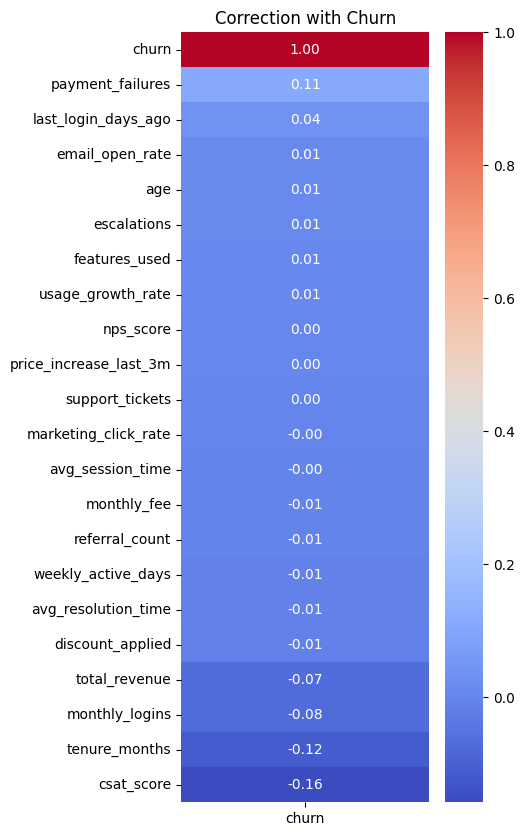

In [5]:
numeric_cols = df.select_dtypes(include = [np.number])

plt.figure(figsize= (4,10) )
sns.heatmap(numeric_cols.corr() [['churn']].sort_values(by='churn', ascending=False),
            annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correction with Churn")
plt.show()

CSAT vs Payment Failures vs Churn

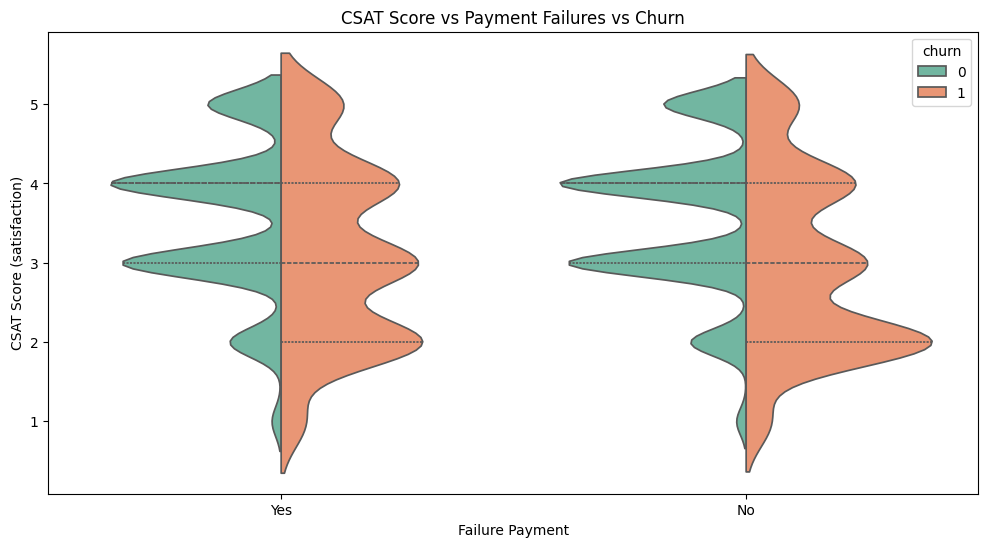

In [6]:

df['has_payment_failure'] = df['payment_failures'].apply(lambda x: 'Yes' if x > 0 else 'No')

plt.figure(figsize = (12, 6))

sns.violinplot(
    data=df,
    x='has_payment_failure',
    y='csat_score',
    hue='churn',
    split=True,      
    inner='quartile',  
    palette='Set2'
)

plt.title('CSAT Score vs Payment Failures vs Churn')
plt.xlabel("Failure Payment")
plt.ylabel('CSAT Score (satisfaction)')
plt.legend(title='churn', loc='upper right')
plt.show()


Retention & Tenure Analysis (when leave)

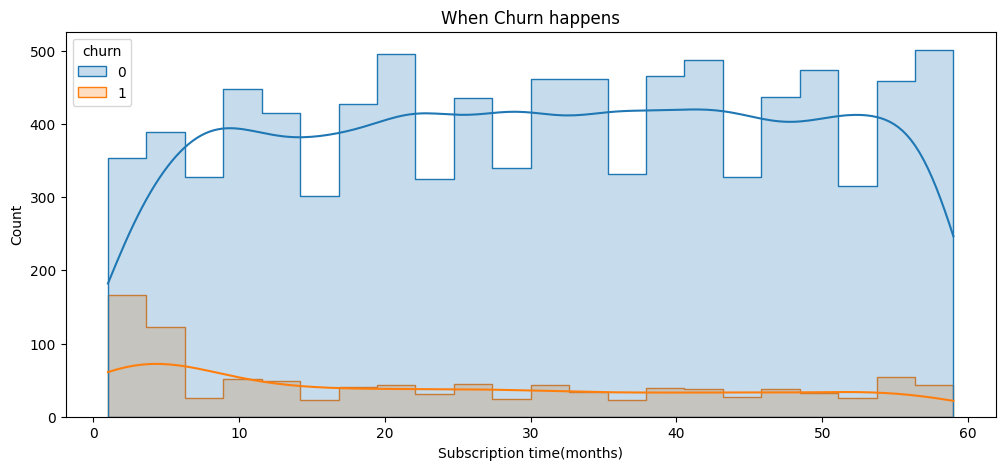

In [7]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='tenure_months', hue='churn', kde=True, element='step')
plt.title("When Churn happens")
plt.xlabel('Subscription time(months)')
plt.show()

Usage Engagement

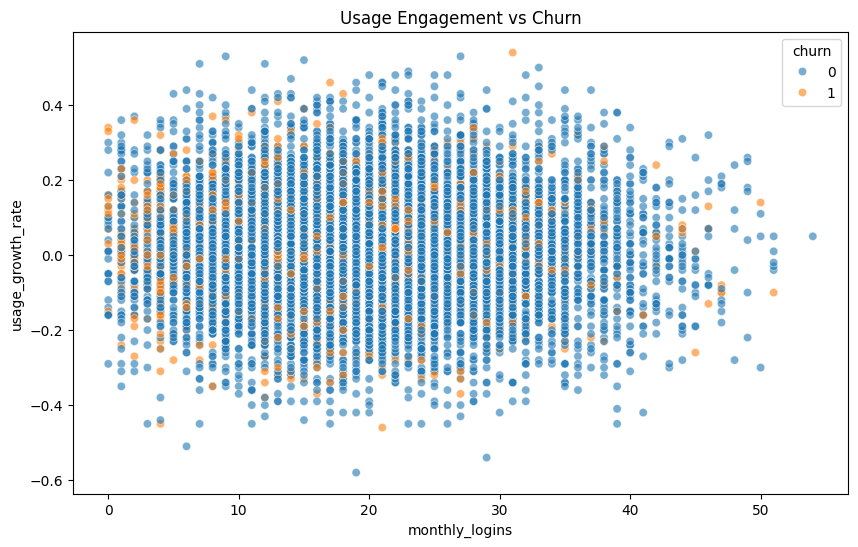

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='monthly_logins', y='usage_growth_rate', hue='churn', alpha=0.6)
plt.title('Usage Engagement vs Churn')
plt.show()

Support & Frustration

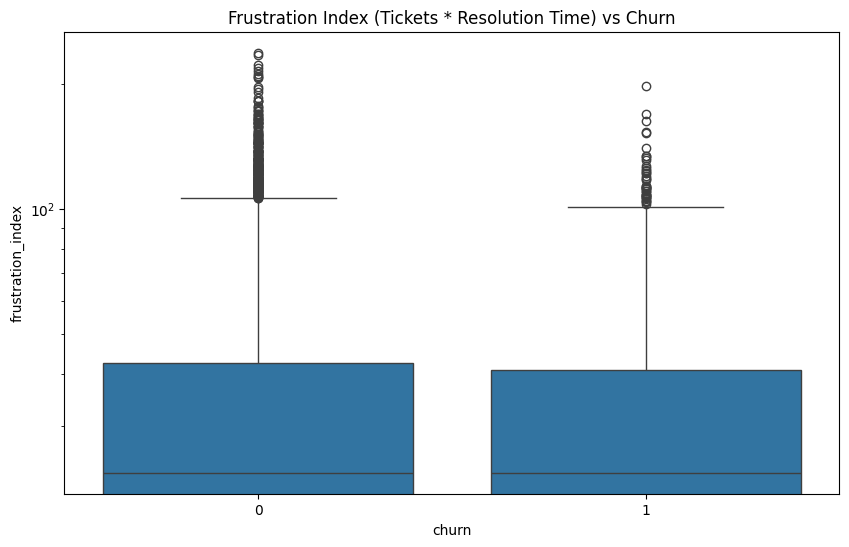

In [9]:
df['frustration_index'] = df['support_tickets'] * df['avg_resolution_time']

plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='frustration_index', data=df)
plt.title('Frustration Index (Tickets * Resolution Time) vs Churn')
plt.yscale('log')
plt.show()

In [10]:
df.groupby('churn')['frustration_index'].median()

churn
0    23.164779
1    23.189098
Name: frustration_index, dtype: float64

Revenue Risk Matrix 

In [11]:
# segmenting Customers by Satisfaction & Billing
def segment_customer(row):
    if row['csat_score'] >= 4 and row ['payment_failures'] > 0:
        return 'Happy but Billing Issues'
    elif row['csat_score'] < 3 and row['payment_failures'] == 0:
        return 'Unhappy'
    elif row['csat_score'] >= 4 and row['payment_failures'] == 0:
        return 'Happy (Safe)'
    else: return 'Other'
    
df['customer_segment'] = df.apply(segment_customer, axis=1)

#MRR each segment

revenue_matrix = df.groupby('customer_segment').agg({
    'monthly_fee': 'sum',
    'churn': 'mean'
}).rename(columns={'churn': 'Churn_Rate'})

revenue_matrix['Churn_Rate'] = revenue_matrix['Churn_Rate'] * 100
print(revenue_matrix)

                          monthly_fee  Churn_Rate
customer_segment                                 
Happy (Safe)                   108080    5.663430
Happy but Billing Issues        69350    9.159537
Other                          139890   10.919108
Unhappy                         31980   24.516129


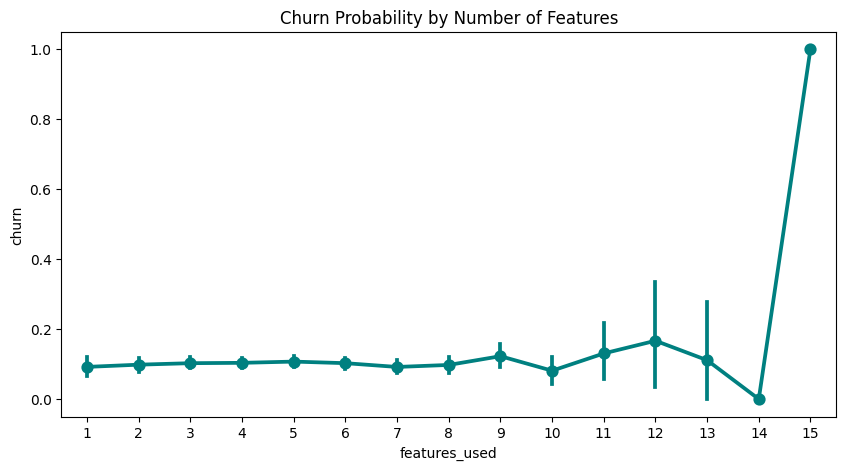

In [12]:
# Features Used with Churn
plt.figure(figsize=(10, 5))
sns.pointplot(data=df, x='features_used', y='churn', color='teal')
plt.title('Churn Probability by Number of Features')
plt.show()